In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

SEED = 42

df = pd.read_csv(
    '../datos/dataset_nlp_utf16_final.csv', 
    encoding='utf-16', 
    sep=',', 
    quoting=csv.QUOTE_ALL, 
    escapechar='\\'
)

# Unificación de textos para comparar
# Esto evita que un NaN destruya el texto de la otra columna al concatenarlos (sumarlos)
# Ejemplo de error anterior ("Conocimientos en Excel" + NaN = NaN)
df['cargo'] = df['cargo'].fillna('')
df['funciones'] = df['funciones'].fillna('')
df['conocimientos'] = df['conocimientos'].fillna('')
df['experiencia'] = df['experiencia'].fillna('')
df['experiencia_cv'] = df['experiencia_cv'].fillna('')
df['estudios_cv'] = df['estudios_cv'].fillna('')

# Juntamos lo que pide la empresa
df['texto_oferta'] = df['cargo'] + " " + df['funciones'] + " " + df['conocimientos'] + " " + df['experiencia']
# Juntamos lo que ofrece el candidato
df['texto_candidato'] = df['experiencia_cv'] + " " + df['estudios_cv']

# Trabajaremos los textos en minúsculas
df['texto_oferta'] = df['texto_oferta'].fillna('').str.lower()
df['texto_candidato'] = df['texto_candidato'].fillna('').str.lower()

print(f"Total de registros listos para análisis: {df.shape[0]}")

Total de registros listos para análisis: 220


In [21]:
# Trabajo adaptado para texto en español
import nltk
from nltk.corpus import stopwords


nltk.download('stopwords')  # Descarga del paquete de stop words
stop_words_es = stopwords.words('spanish')  # Crea una lista con las palabras vacías en español

print("Vectorizando textos con TF-IDF en español.")

vectorizador = TfidfVectorizer(max_features=5000, stop_words=stop_words_es)

# Ajusta el vocabulario usando tanto las ofertas como los CVs
corpus_completo = pd.concat([df['texto_oferta'], df['texto_candidato']])
vectorizador.fit(corpus_completo)

# Transforma textos a matrices numéricas
tfidf_ofertas = vectorizador.transform(df['texto_oferta'])
tfidf_candidatos = vectorizador.transform(df['texto_candidato'])

# Calcula la similitud del coseno fila por fila
similitudes = []
for i in range(df.shape[0]):
    # Calcula qué tan cerca está el vector del CV al vector de la Oferta (1 = Idéntico, 0 = Ninguna similitud)
    similitud = cosine_similarity(tfidf_ofertas[i], tfidf_candidatos[i])[0][0]
    similitudes.append(similitud)

df['score_similitud'] = similitudes
print("Similitud calculada. Muestra de los primeros 5 scores:")
print(df[['target_elegibilidad', 'score_similitud']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Vectorizando textos con TF-IDF en español.
Similitud calculada. Muestra de los primeros 5 scores:
   target_elegibilidad  score_similitud
0                    1         0.064945
1                    1         0.052568
2                    1         0.033694
3                    1         0.000000
4                    1         0.211424


In [22]:
# Calcula cantidades y porcentajes
total_filas = len(df)
filas_cero = (df['score_similitud'] == 0.0).sum()
porcentaje_ceros = (filas_cero / total_filas) * 100

print(f"Total de registros evaluados: {total_filas}")
print(f"Registros con similitud exacta de 0.0: {filas_cero}")
print(f"Porcentaje de ceros en el dataset: {porcentaje_ceros:.2f}%\n")

Total de registros evaluados: 220
Registros con similitud exacta de 0.0: 54
Porcentaje de ceros en el dataset: 24.55%



In [23]:
print("Iniciando entrenamiento del modelo de Línea Base.\n")

X = df[['score_similitud']]
y = df['target_elegibilidad'].astype(int)   # binario: 1 (Elegible) o 0 (No Elegible)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Datos para entrenar: {len(X_train)} filas.")
print(f"Datos para evaluar: {len(X_test)} filas.\n")

modelo_base = LogisticRegression(class_weight='balanced')
modelo_base.fit(X_train, y_train)

y_pred = modelo_base.predict(X_test)

Iniciando entrenamiento del modelo de Línea Base.

Datos para entrenar: 176 filas.
Datos para evaluar: 44 filas.



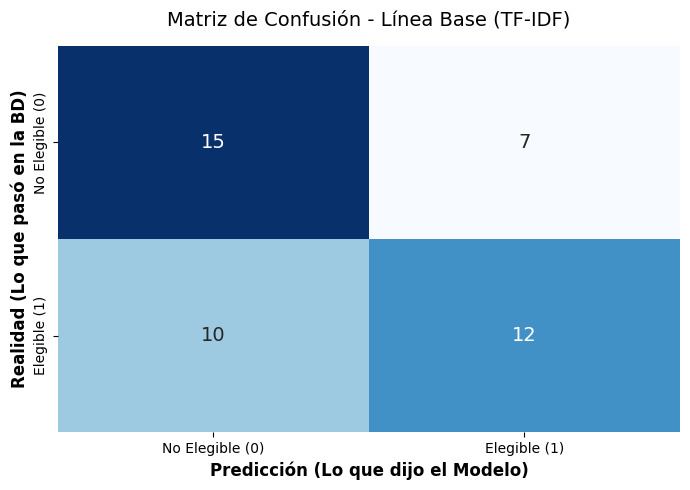

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Elegible (0)', 'Elegible (1)'],
            yticklabels=['No Elegible (0)', 'Elegible (1)'],
            annot_kws={"size": 14})

plt.title('Matriz de Confusión - Línea Base (TF-IDF)', fontsize=14, pad=15)
plt.ylabel('Realidad (Lo que pasó en la BD)', fontsize=12, fontweight='bold')
plt.xlabel('Predicción (Lo que dijo el Modelo)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
print(" RESULTADOS DE LA LÍNEA BASE [TF-IDF + (Regresión Logística - emplea función sigmoide)]")
print("Reporte de Clasificación Detallado (Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred))

 RESULTADOS DE LA LÍNEA BASE [TF-IDF + (Regresión Logística - emplea función sigmoide)]
Reporte de Clasificación Detallado (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.60      0.68      0.64        22
           1       0.63      0.55      0.59        22

    accuracy                           0.61        44
   macro avg       0.62      0.61      0.61        44
weighted avg       0.62      0.61      0.61        44



In [26]:
print("Cargando el modelo de lenguaje pre-entrenado (Multilingüe/Español).")
modelo_emb = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

Cargando el modelo de lenguaje pre-entrenado (Multilingüe/Español).


In [27]:
print("Generando vectores densos (embeddings) para ofertas y candidatos.")
embeddings_ofertas = modelo_emb.encode(df['texto_oferta'].tolist(), show_progress_bar=True)
embeddings_candidatos = modelo_emb.encode(df['texto_candidato'].tolist(), show_progress_bar=True)

Generando vectores densos (embeddings) para ofertas y candidatos.


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

In [28]:
# Calcula la nueva similitud del coseno basada en el contexto semántico
similitudes_semanticas = []
for i in range(df.shape[0]):
    similitud = cosine_similarity([embeddings_ofertas[i]], [embeddings_candidatos[i]])[0][0]
    similitudes_semanticas.append(similitud)

df['score_semantico'] = similitudes_semanticas

print("\nSimilitud semántica calculada. Comparativa de los primeros 5 scores:")
print(df[['target_elegibilidad', 'score_similitud', 'score_semantico']].head())


Similitud semántica calculada. Comparativa de los primeros 5 scores:
   target_elegibilidad  score_similitud  score_semantico
0                    1         0.064945         0.456486
1                    1         0.052568         0.436292
2                    1         0.033694         0.483938
3                    1         0.000000         0.409943
4                    1         0.211424         0.360955


In [29]:
print("Iniciando entrenamiento del modelo con la nueva Variante.")
X_sem = df[['score_semantico']]
y_sem = df['target_elegibilidad'].astype(int)

X_train_sem, X_test_sem, y_train_sem, y_test_sem = train_test_split(
    X_sem, y_sem, test_size=0.2, random_state=SEED, stratify=y_sem
)

# Se mantiene la Regresión Logística para poder hacer una comparación justa
modelo_variante = LogisticRegression(class_weight='balanced')
modelo_variante.fit(X_train_sem, y_train_sem)

y_pred_sem = modelo_variante.predict(X_test_sem)

print(" RESULTADOS DE LA VARIANTE (Embeddings + Regresión Logística)")
print("Reporte de Clasificación Detallado (Precision, Recall, F1-score):")
print(classification_report(y_test_sem, y_pred_sem))

Iniciando entrenamiento del modelo con la nueva Variante.
 RESULTADOS DE LA VARIANTE (Embeddings + Regresión Logística)
Reporte de Clasificación Detallado (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.71      0.55      0.62        22
           1       0.63      0.77      0.69        22

    accuracy                           0.66        44
   macro avg       0.67      0.66      0.65        44
weighted avg       0.67      0.66      0.65        44



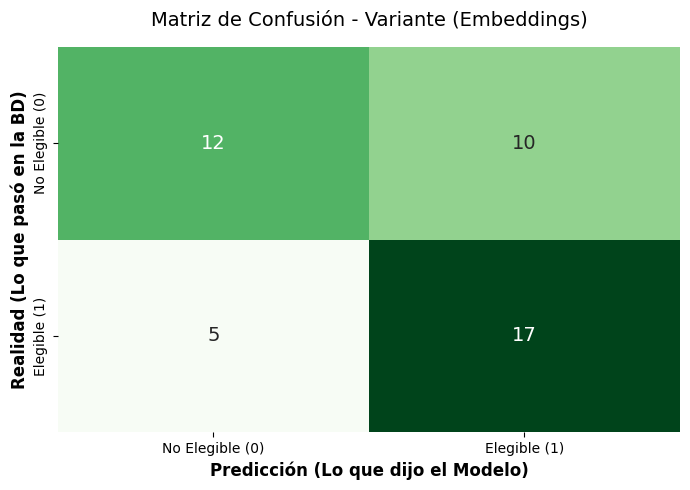

In [30]:
cm_sem = confusion_matrix(y_test_sem, y_pred_sem)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_sem, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Elegible (0)', 'Elegible (1)'],
            yticklabels=['No Elegible (0)', 'Elegible (1)'],
            annot_kws={"size": 14})

plt.title('Matriz de Confusión - Variante (Embeddings)', fontsize=14, pad=15)
plt.ylabel('Realidad (Lo que pasó en la BD)', fontsize=12, fontweight='bold')
plt.xlabel('Predicción (Lo que dijo el Modelo)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Tabla Resumen de Rendimiento:


Métrica,Accuracy,F1-Score
Modelo,,
Línea Base (TF-IDF),0.613636,0.611832
Variante (Embeddings),0.659091,0.654631


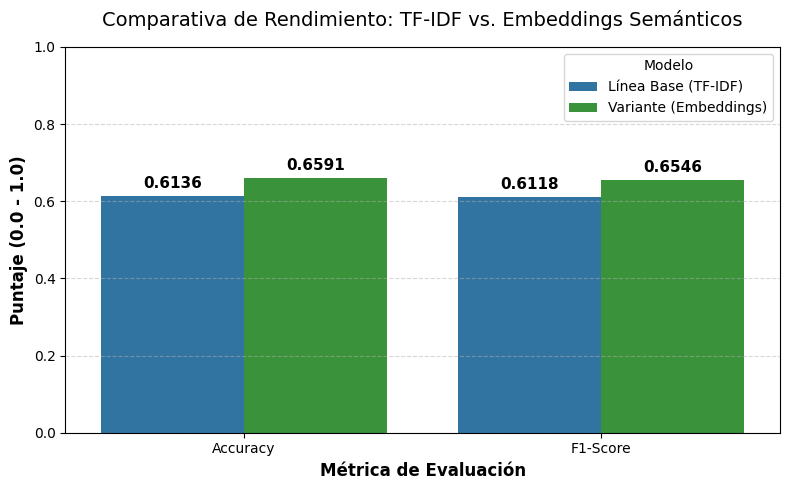

In [31]:
# Métricas del modelo TF-IDF (Base)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

# Métricas del modelo de Embeddings (Variante)
accuracy_sem = accuracy_score(y_test_sem, y_pred_sem)
f1_sem = f1_score(y_test_sem, y_pred_sem, average='weighted')

data_metricas = {
    'Modelo': ['Línea Base (TF-IDF)', 'Línea Base (TF-IDF)', 'Variante (Embeddings)', 'Variante (Embeddings)'],
    'Métrica': ['Accuracy', 'F1-Score', 'Accuracy', 'F1-Score'],
    'Valor': [accuracy, f1, accuracy_sem, f1_sem]
}

df_metricas = pd.DataFrame(data_metricas)

print("Tabla Resumen de Rendimiento:")
display(df_metricas.pivot(index='Modelo', columns='Métrica', values='Valor'))

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Métrica', y='Valor', hue='Modelo', data=df_metricas, palette=['#1f77b4', '#2ca02c'])

plt.title('Comparativa de Rendimiento: TF-IDF vs. Embeddings Semánticos', fontsize=14, pad=15)
plt.ylim(0, 1.0)
plt.ylabel('Puntaje (0.0 - 1.0)', fontsize=12, fontweight='bold')
plt.xlabel('Métrica de Evaluación', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.4f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
import re

def extraer_evidencia_textual(texto_oferta, texto_candidato, stop_words):
    # Limpieza básica y tokenización mediante expresiones regulares
    tokens_oferta = set(re.findall(r'\b[a-záéíóúñ\+\#]{3,}\b', texto_oferta.lower()))
    tokens_candidato = set(re.findall(r'\b[a-záéíóúñ\+\#]{3,}\b', texto_candidato.lower()))
    
    # Filtrado de palabras vacías (stop words) para conservar solo léxico de valor
    palabras_clave_oferta = {w for w in tokens_oferta if w not in stop_words}
    palabras_clave_candidato = {w for w in tokens_candidato if w not in stop_words}
    
    # Intersección de conjuntos para hallar las coincidencias exactas
    coincidencias = palabras_clave_oferta.intersection(palabras_clave_candidato)
    
    # Formatear la salida textual explicativa
    if coincidencias:
        evidencia = ", ".join(sorted(coincidencias))
        explicacion = f"Evidencia encontrada: Se identificaron las siguientes competencias, términos técnicos o requisitos clave compartidos en ambos perfiles: [{evidencia}]."
    else:
        explicacion = "Atención: No se encontraron palabras clave compartidas explícitas. La evaluación depende puramente de la proximidad del contexto semántico abstracto."
        
    return explicacion

# Pruebemos el motor con un caso real del dataset (Fila 1) para verificar su funcionamiento
ejemplo_oferta = df['texto_oferta'].iloc[1]
ejemplo_candidato = df['texto_candidato'].iloc[1]

print("PRUEBA DEL MOTOR DE EVIDENCIA (Fila 1)")
justificacion = extraer_evidencia_textual(ejemplo_oferta, ejemplo_candidato, stop_words_es)
print(justificacion)

PRUEBA DEL MOTOR DE EVIDENCIA (Fila 1)
Evidencia encontrada: Se identificaron las siguientes competencias, términos técnicos o requisitos clave compartidos en ambos perfiles: [control, diseño, experiencia, inglés, proyectos, sistemas].


In [33]:
def evaluar_candidato(oferta, perfil, modelo_emb, modelo_clf, stop_words):
    print("EVALUACIÓN AUTOMATIZADA DE POSTULANTE (MOTOR HÍBRIDO)")
    
    # Generar Embeddings Semánticos
    emb_oferta = modelo_emb.encode([oferta])
    emb_perfil = modelo_emb.encode([perfil])
    
    # Calcular Score de Similitud Semántica
    score_sem = cosine_similarity(emb_oferta, emb_perfil)[0][0]
    
    # Predicción con Regresión Logística (El modelo exige estructura 2D de Pandas)
    df_nuevo = pd.DataFrame({'score_semantico': [score_sem]})
    prediccion = modelo_clf.predict(df_nuevo)[0]
    
    # Extracción de Evidencia
    evidencia = extraer_evidencia_textual(oferta, perfil, stop_words)

    resultado = "ELEGIBLE (Target: 1)" if prediccion == 1 else "NO ELEGIBLE (Target: 0)"
    
    print(f"DECISIÓN DEL ALGORITMO : {resultado}")
    print(f"PUNTAJE DE COMPATIBILIDAD: {score_sem:.4f} (Basado en Embeddings)")
    print(evidencia)

In [34]:
# Simulación
nueva_oferta_laboral = "Docente especialista en Análisis de Datos con Excel. Requisitos: Dominio avanzado de macros, tablas dinámicas y power query. Capacidad de liderazgo y empatía para la enseñanza técnica e ingeniería."
nuevo_perfil_candidato = "Profesional de ingeniería con 5 años de experiencia en automatización de reportes usando macros en Excel. Habilidades sólidas en tablas dinámicas. Destaco por mi liderazgo, comunicación efectiva y empatía con equipos de trabajo."

evaluar_candidato(nueva_oferta_laboral, nuevo_perfil_candidato, modelo_emb, modelo_variante, stop_words_es)

EVALUACIÓN AUTOMATIZADA DE POSTULANTE (MOTOR HÍBRIDO)
DECISIÓN DEL ALGORITMO : ELEGIBLE (Target: 1)
PUNTAJE DE COMPATIBILIDAD: 0.8352 (Basado en Embeddings)
Evidencia encontrada: Se identificaron las siguientes competencias, términos técnicos o requisitos clave compartidos en ambos perfiles: [dinámicas, empatía, excel, ingeniería, liderazgo, macros, tablas].
